In [1]:
import pandas as pd
import numpy as np
import pandahouse as ph

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
connection = {...}  # Здесь должны быть сведения для подключения к базе данных

## A/A-тест

A/A-тест проводился с 26.08.2025 по 1.09.2025 в группах 1 и 2. Группа 1 - контрольная группа (в ней все по-старому), группа 2 - тестовая (в ней новая функциональность). Перед проведением непосредственно A/B-теста необходимо удостовериться, что наши группы статистически эквивалентны.

In [3]:
query = '''
    SELECT
        user_id,
        exp_group,
        countIf(action='view') AS views,
        countIf(action='like') AS likes,
        likes/views AS ctr
    FROM {db}.feed_actions
    WHERE (toDate(time) BETWEEN '2025-08-26' AND '2025-09-01') AND (exp_group IN (1, 2))
    GROUP BY exp_group, user_id
    '''

In [4]:
df = ph.read_clickhouse(query, connection=connection)
df.head()

,user_id,exp_group,views,likes,ctr
0,109963,1,34,10,0.294118
1,18392,1,56,13,0.232143
2,131473,2,98,19,0.193878
3,23985,2,44,12,0.272727
4,24523,2,10,2,0.200000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16853 entries, 0 to 16852
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    16853 non-null  uint32 
 1   exp_group  16853 non-null  int8   
 2   views      16853 non-null  uint64 
 3   likes      16853 non-null  uint64 
 4   ctr        16853 non-null  float64
dtypes: float64(1), int8(1), uint32(1), uint64(2)
memory usage: 477.4 KB


Для начала посмотрим на данные глазами.

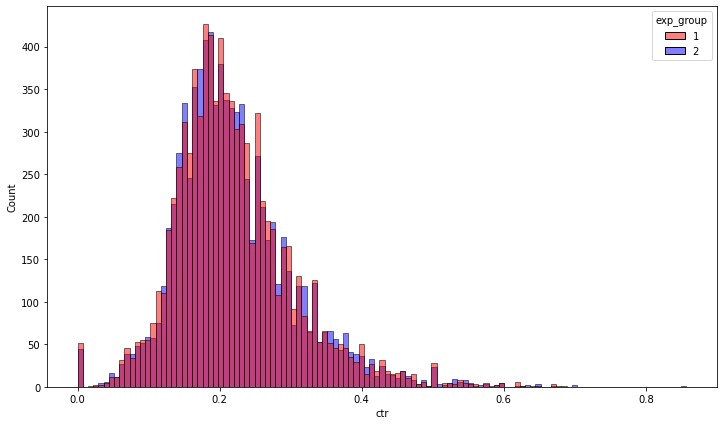

In [6]:
plt.figure(figsize=(12, 7))
sns.histplot(
    data=df, 
    x='ctr', 
    hue='exp_group', 
    palette = ['r', 'b'],
    alpha=0.5,
    kde=False
);

In [7]:
df.loc[df['exp_group'] == 1, 'ctr'].describe()

count    8491.000000
mean        0.219471
std         0.083897
min         0.000000
25%         0.166667
50%         0.206731
75%         0.260000
max         0.857143
Name: ctr, dtype: float64

In [8]:
df.loc[df['exp_group'] == 2, 'ctr'].describe()

count    8362.000000
mean        0.220207
std         0.083804
min         0.000000
25%         0.166667
50%         0.206522
75%         0.260870
max         0.700000
Name: ctr, dtype: float64

Видно, что распределения практически совпадают. Проведем серию t-тестов на 10000 подвыборках без возвращения. После посмотрим на распределение p_value и оценим долю "прокрасившихся" (то есть отвергнувших нулевую гипотезу о равенстве средних в выборках) тестов.

In [9]:
p_values = []
for i in range(10000):
    group1_sample = df.loc[df['exp_group'] == 1, 'ctr'].sample(500, replace=False).tolist()
    group2_sample = df.loc[df['exp_group'] == 2, 'ctr'].sample(500, replace=False).tolist()
    
    statistic, p_value = stats.ttest_ind(group1_sample, group2_sample, equal_var=False)
    
    p_values.append(p_value)

p_values = np.array(p_values)

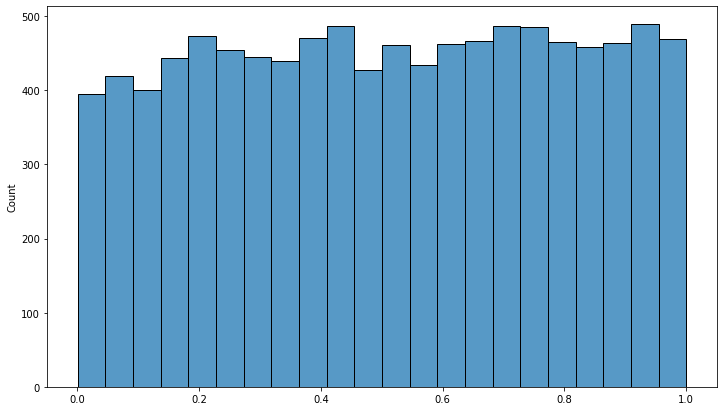

In [10]:
plt.figure(figsize=(12, 7))
sns.histplot(data=p_values);

In [11]:
p_values[p_values < 0.05].shape[0] / p_values.shape[0]

0.0431

Видно, что распределение p_value напоминает равномерное. Доля значений, меньших 5% составляет всего 0,0431. Значит, нулевая гипотеза была отвергнута лишь примерно в 4,3% случаев. Таким образом, можно сделать вывод о том, что до начала проведения A/B-теста группы 1 и 2 были статистически эквивалентными.

## A/B-тест

Первый этап теста - формулировка гипотезы.

$H_0:$ CTR одинаковый в группах 1 и 2.

$H_1:$ Новый алгоритм во 2-й группе приведет к увеличению CTR.

Теперь перейдем собственно к тестированию. Но прежде посмотрим на данные глазами.

In [12]:
query = '''
    SELECT
        user_id,
        exp_group,
        countIf(action='view') AS views,
        countIf(action='like') AS likes,
        likes/views AS ctr
    FROM {db}.feed_actions
    WHERE (toDate(time) BETWEEN '2025-09-02' AND '2025-09-08') AND (exp_group IN (1, 2))
    GROUP BY exp_group, user_id
    '''

In [13]:
df = ph.read_clickhouse(query, connection=connection)
df.head()

,user_id,exp_group,views,likes,ctr
0,109963,1,15,3,0.200000
1,26117,1,141,32,0.226950
2,138232,1,73,18,0.246575
3,26295,1,141,39,0.276596
4,18392,1,32,7,0.218750


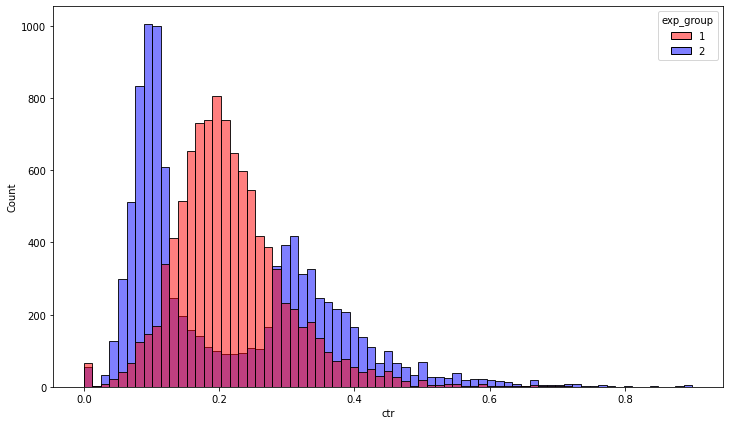

In [14]:
plt.figure(figsize=(12, 7))
sns.histplot(
    data=df, 
    x='ctr', 
    hue='exp_group', 
    palette = ['r', 'b'],
    alpha=0.5,
    kde=False
);

In [15]:
df.loc[df['exp_group'] == 1, 'ctr'].describe()

count    10020.000000
mean         0.216774
std          0.082969
min          0.000000
25%          0.163636
50%          0.205882
75%          0.257870
max          0.722222
Name: ctr, dtype: float64

In [16]:
df.loc[df['exp_group'] == 2, 'ctr'].describe()

count    9877.000000
mean        0.216102
std         0.142870
min         0.000000
25%         0.096774
50%         0.153285
75%         0.323529
max         0.900000
Name: ctr, dtype: float64

Заметим, что распределение значений CTR в группе 1 визуально слабо отличается от распределения до начала A/B-теста (напомним, что в группе 1 у нас все по-старому, новую функциональность не выкатывали). Зато распределение CTR в группе 2 существенно изменилось: оно стало бимодальным (стоит заметить, что средние значения в обеих группах по-прежнему практически одинаковы).

A/B-тест можно проводить по-разному, в том числе с использованием t-теста, теста Манна-Уитни, Пуассоновского бутстрепа, t-теста на сглаженном ctr (a=5), а также t-теста и теста Манна-Уитни поверх бакетного преобразования. Однако в нашем случае использование t-теста не является корректным ввиду неподходящего распределения CTR в тестовой группе. Начнем с теста Манна-Уитни, который менее требователен к распределениям данных в анализируемых выборках.

#### Тест Манна-Уитни

Тест Манна-Уитни, по сути, проверяет гипотезу о равенстве распределений элементов выборок. Стало быть, в нашем случае нулевая гипотеза для этого теста должна звучать так: распределения CTR в тестовой (2) и контрольной (1) группах равны. Альтернатива, соответственно, говорит, что не равны.

In [17]:
stats.mannwhitneyu(df.loc[df.exp_group == 1, 'ctr'], df.loc[df.exp_group == 2, 'ctr'])

MannwhitneyuResult(statistic=55189913.0, pvalue=4.632205841806026e-45)

Тест выдал p_value < 0.05, значит, мы вынуждены отвергнуть нулевую гипотезу о равенстве распределений, что в целом логично, так как визуально распределения отличаются сильно. Кроме того, по графику распределений CTR видно, что ситуация в группе 2 неоднозначная: с одной стороны часть группы действительно стала активнее ставить лайки, но с другой - часть народу стала лайкать меньше... Чтобы точно ответить на вопрос, проведем еще несколько тестов.

#### Пуассоновский бутстреп

Теперь займемся реализацией пуассоновского бутстрепа. Функцию, отвечающую, собственно, за бутстреп, возьмем из лекционного материала.

In [18]:
def bootstrap(likes1, views1, likes2, views2, n_bootstrap=2000):

    poisson_bootstraps1 = stats.poisson(1).rvs((n_bootstrap, len(likes1))).astype(np.int64)
    poisson_bootstraps2 = stats.poisson(1).rvs((n_bootstrap, len(likes2))).astype(np.int64)
    
    globalCTR1 = (poisson_bootstraps1 * likes1).sum(axis=1) / (poisson_bootstraps1 * views1).sum(axis=1)
    globalCTR2 = (poisson_bootstraps2 * likes2).sum(axis=1) / (poisson_bootstraps2 * views2).sum(axis=1)

    return globalCTR1, globalCTR2

In [19]:
likes1 = df.loc[df.exp_group == 1, 'likes'].to_numpy()
views1 = df.loc[df.exp_group == 1, 'views'].to_numpy()
likes2 = df.loc[df.exp_group == 2, 'likes'].to_numpy()
views2 = df.loc[df.exp_group == 2, 'views'].to_numpy()

ctr1, ctr2 = bootstrap(likes1, views1, likes2, views2)

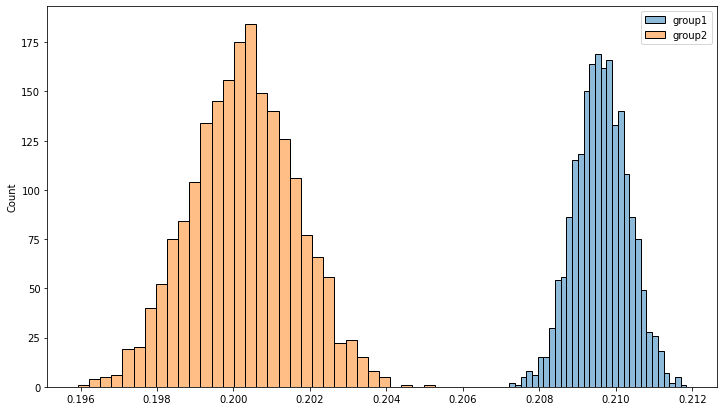

In [20]:
plt.figure(figsize=(12, 7))
sns.histplot(ctr1, alpha=0.5, kde=False, label='group1')
sns.histplot(ctr2, alpha=0.5, kde=False, label='group2')
plt.legend();

Видно, что распределения достаточно далеко отстоят друг от друга. Построим также распределение разницы значений "глобального CTR".

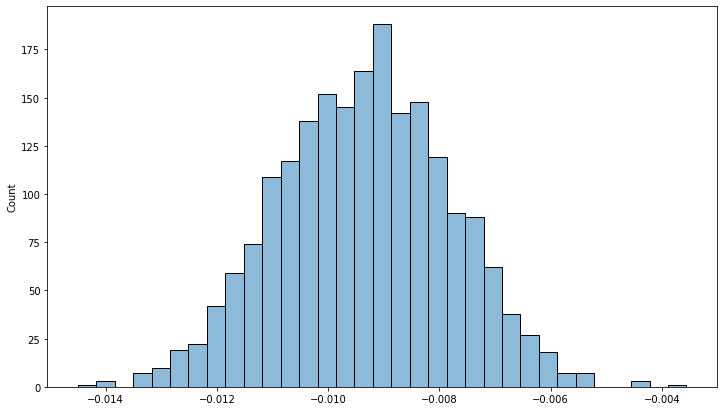

In [21]:
plt.figure(figsize=(12, 7))
sns.histplot(ctr2 - ctr1, alpha=0.5, kde=False);

Все значения в нашем распределении отрицательны. Это означает, что распределения "глобального CTR" в группах 1 и 2 не пересекаются. Следовательно, при проведении t-теста на этих распределениях (а его можно проводить, так как распределения похожи на нормальное) получим p_value=0. Значит, нулевая гипотеза о равенстве средних отвергается. Так как распределение "глобального CTR" для группы 1 находится правее распределения для группы 2, то мы вынуждены сделать вывод о том, что новый алгоритм рекомендаций справляется со своей задачей хуже, чем старый.

#### Бакетное преобразование

Ну и последняя техника, которую мы попробуем применить - это бакетное преобразование. Каждую группу будем делить на 50 бакетов (это значение часто используется в индустрии). Деление производится с помощью хеширования.

In [22]:
q = '''
    SELECT exp_group, bucket,
        SUM(likes) / SUM(views) AS bucket_ctr
    FROM (
        SELECT
            exp_group,
            xxHash64(user_id)%50 AS bucket,
            user_id,
            SUM(action='like') AS likes,
            SUM(action='view') AS views
        FROM {db}.feed_actions 
        WHERE (toDate(time) BETWEEN '2025-09-02' AND '2025-09-08') AND (exp_group IN (1, 2))
        GROUP BY exp_group, bucket, user_id
        )
    GROUP BY exp_group, bucket
    '''

bucket_df = ph.read_clickhouse(q, connection=connection)

In [23]:
bucket_df.head()

,exp_group,bucket,bucket_ctr
0,1,0,0.200592
1,2,0,0.196510
2,1,1,0.208799
3,2,1,0.210375
4,1,2,0.204632


In [24]:
bucket_df.shape

(100, 3)

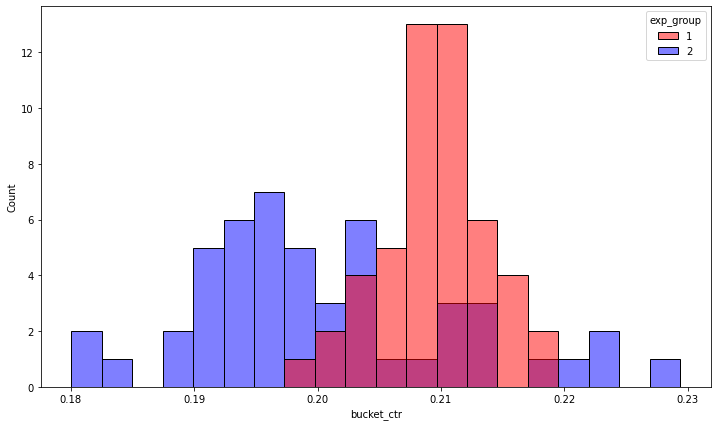

In [25]:
plt.figure(figsize=(12, 7))
sns.histplot(
    data=bucket_df, 
    x='bucket_ctr', 
    hue='exp_group', 
    palette=['r', 'b'],
    alpha=0.5,
    kde=False,
    bins=20
);

Видно, что распределение бакетных CTR в группе 1 чем-то похоже на нормальное, а аналогичное распределение в группе 2 похоже на нормальное лишь с очень большой натяжкой. При этом даже визуальный анализ говорит о том, что распределения достаточно сильно различаются по форме, а среднее значение бакетного CTR в группе 1 больше среднего значения бакетного CTR в группе 2. Но чтобы точно в этом удостовериться, проведем тест. T-тест будет не лучшим выбором в данной ситуации, поэтому воспользуемся тетсом Манна-Уитни.

In [26]:
stats.mannwhitneyu(
    bucket_df.loc[bucket_df['exp_group'] == 1, 'bucket_ctr'],
    bucket_df.loc[bucket_df['exp_group'] == 2, 'bucket_ctr'],
    alternative='two-sided'
)

MannwhitneyuResult(statistic=1997.0, pvalue=2.6576427804010095e-07)

In [27]:
bucket_df.groupby('exp_group', as_index=False)['bucket_ctr'].mean().rename(columns={'bucket_ctr': 'avg_bucket_ctr'})

,exp_group,avg_bucket_ctr
0,1,0.209694
1,2,0.200457


Тест Манна-Уитни видит различие. А так как среднее значение бакетного CTR в группе 1 больше, чем в группе 2, то делаем вывод, что новый алгоритм рекомендаций себя не оправдал.

## Вывод

1) Обнаружено, что CTR в тестовой группе имеет бимодальное распределение, при этом его среднее значение не отличается от среднего значения в контрольной группе.
2) A/B-тестирование проведено с использованием следующих методов: теста Манна-Уитни, Пуассоновского бутстрепа с последующим применением t-теста для анализа распределений "глобального CTR" и бакетного преобразования с применением теста Манна-Уитни. Все тесты показали значимое различие выборок, что позволило сделать вывод о том, что изменение алгоритма рекомендаций влияет на метрики. Однако с помощью сравнения средних значений было выяснено, что это влияние носит негативный характер.
3) По результатам теста рекомендуется **НЕ** раскатывать новый алгоритм (который был протестирован на группе 2) на всех пользователей.